In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chart_studio.plotly import plot,iplot
import cufflinks as cf
import seaborn as sns
%matplotlib inline
import os


In [ ]:
df= pd.read_excel(r"E:\ML_Pro\Flight_Price_Prd\data\Data_Train.xlsx")
display(df)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [7]:
import pandas_profiling as pf
display(pf.ProfileReport(df))


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:01<00:00, 10.11it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
df.duplicated().sum()

np.int64(220)

In [9]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [10]:
len(df)

10683

In [11]:
display (df.shape)

(10683, 11)

In [12]:
display (df.dtypes )

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [13]:
df.dropna(how='any',inplace=True)
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

Feature Engineering

In [14]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [15]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
display(df.head())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


Split Date of Journey column to Day and Month 

In [16]:
df['Day_of_Journey']=(df['Date_of_Journey']).dt.day # Day column 
df['Month_of_Journey']=(df['Date_of_Journey']).dt.month # Month Column 
display(df)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


In [17]:
df.drop(['Date_of_Journey'], axis=1, inplace=True)
display(df)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


Split Dep_Time column to hour and minutes 

In [18]:
df['Dep_hr']=pd.to_datetime(df['Dep_Time'],format='%H:%M').dt.hour
df['Dep_min']=pd.to_datetime(df['Dep_Time'],format='%H:%M').dt.minute
display(df.head())


,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [19]:
df['Arrival_hr'] = pd.to_datetime(df['Arrival_Time'], format='mixed').dt.hour
df['Arrival_min'] =pd.to_datetime(df['Arrival_Time'], format='mixed').dt.minute
display(df.head())

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


Drop the column 'Arrival_Time'

In [20]:
df.drop(['Arrival_Time'], axis=1, inplace=True)
display(df.head())

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


Extract hours and minutes from duration

In [21]:
display(df['Duration'])

0        2h 50m
1        7h 25m
2           19h
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680        3h
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

Split Duration into two columns hours and minutes 

Split Duration into two columns hours and minutes 

In [22]:
duration=df['Duration'].str.split(' ',expand=True) 
display (duration)


,0,1
0,2h,50m
1,7h,25m
2,19h,None
3,5h,25m
4,4h,45m
...,...,...
10678,2h,30m
10679,2h,35m
10680,3h,None
10681,2h,40m


In column 1 ie minutes column fill all NULL values with ‘00m'

In [23]:
duration[1] = duration[1].fillna('OOM')
display(duration)

,0,1
0,2h,50m
1,7h,25m
2,19h,OOM
3,5h,25m
4,4h,45m
...,...,...
10678,2h,30m
10679,2h,35m
10680,3h,OOM
10681,2h,40m


In [24]:
df['Duration_hr'] = duration[1].apply(lambda x:x[1])
display(df['Duration_hr'])

0        0
1        5
2        O
3        5
4        5
        ..
10678    0
10679    5
10680    O
10681    0
10682    0
Name: Duration_hr, Length: 10682, dtype: object


Extract Minutes


In [25]:
df['duration_min'] = duration[1].apply(lambda x:x[-1])
display(df['duration_min'])

0        m
1        m
2        M
3        m
4        m
        ..
10678    m
10679    m
10680    M
10681    m
10682    m
Name: duration_min, Length: 10682, dtype: object

In [26]:
df.drop(["Duration"],axis=1,inplace=True)
display (df)


,Airline,Source,Destination,Route,Dep_Time,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,Duration_hr,duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,non-stop,No info,3897,24,3,22,20,1,10,0,m
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,2 stops,No info,7662,1,5,5,50,13,15,5,m
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,2 stops,No info,13882,9,6,9,25,4,25,O,M
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,1 stop,No info,6218,12,5,18,5,23,30,5,m
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,1 stop,No info,13302,1,3,16,50,21,35,5,m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,19:55,non-stop,No info,4107,9,4,19,55,22,25,0,m
10679,Air India,Kolkata,Banglore,CCU → BLR,20:45,non-stop,No info,4145,27,4,20,45,23,20,5,m
10680,Jet Airways,Banglore,Delhi,BLR → DEL,08:20,non-stop,No info,7229,27,4,8,20,11,20,O,M
10681,Vistara,Banglore,New Delhi,BLR → DEL,11:30,non-stop,No info,12648,1,3,11,30,14,10,0,m


Config file

Visualizations

In [28]:
cf.set_config_file(theme='ggplot',sharing='public',offline=True)

Count of Airlines 

In [29]:
print(df['Airline'].value_counts())



Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64


Airline VS average Price

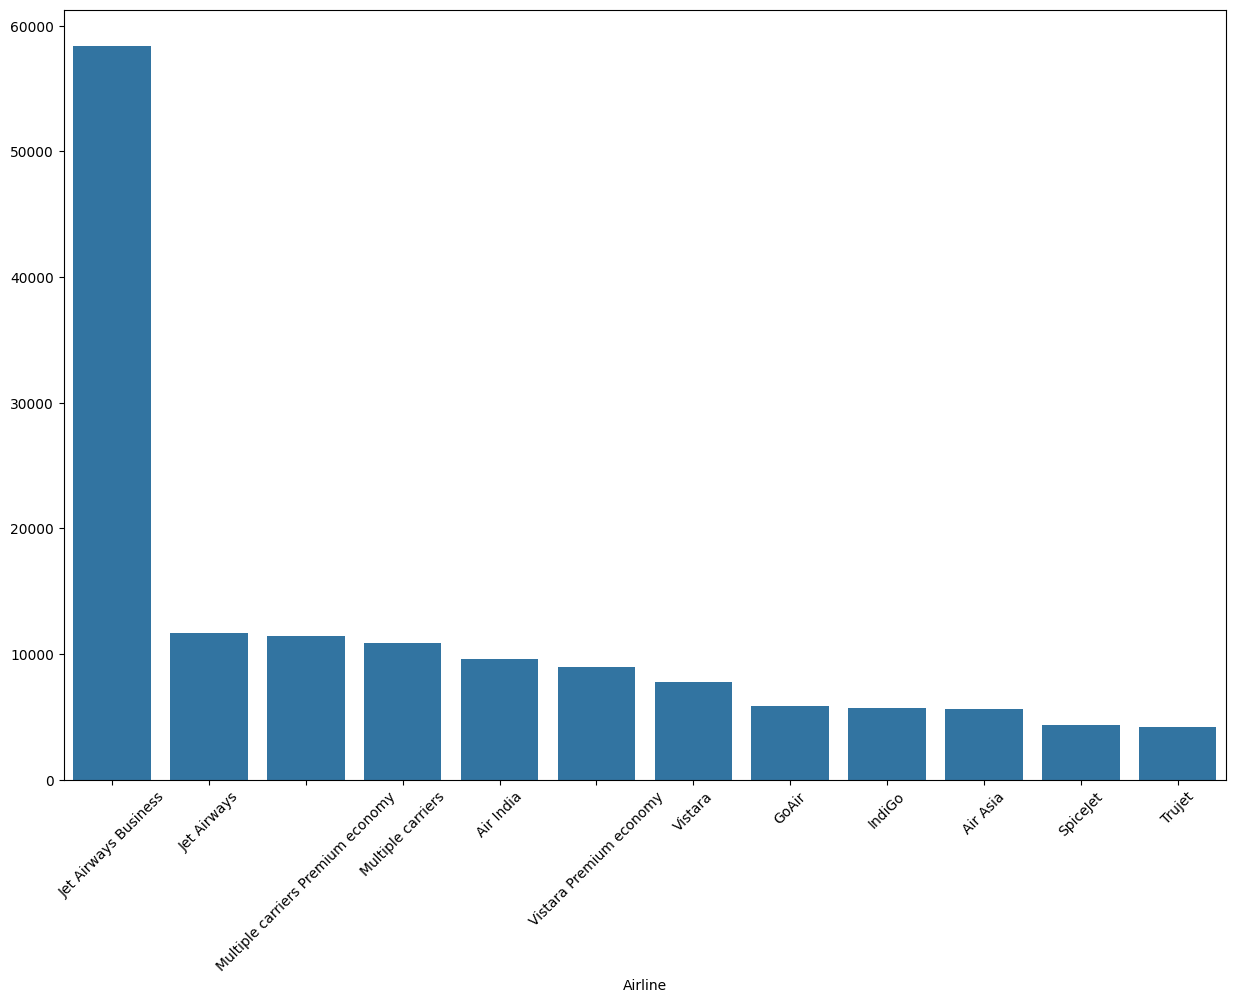

In [31]:
Airprices = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,10))
sns.barplot(x =Airprices.index, y=Airprices.values)
plt.xticks(rotation=45)
plt.show()

Box Plot Airline VS Price	

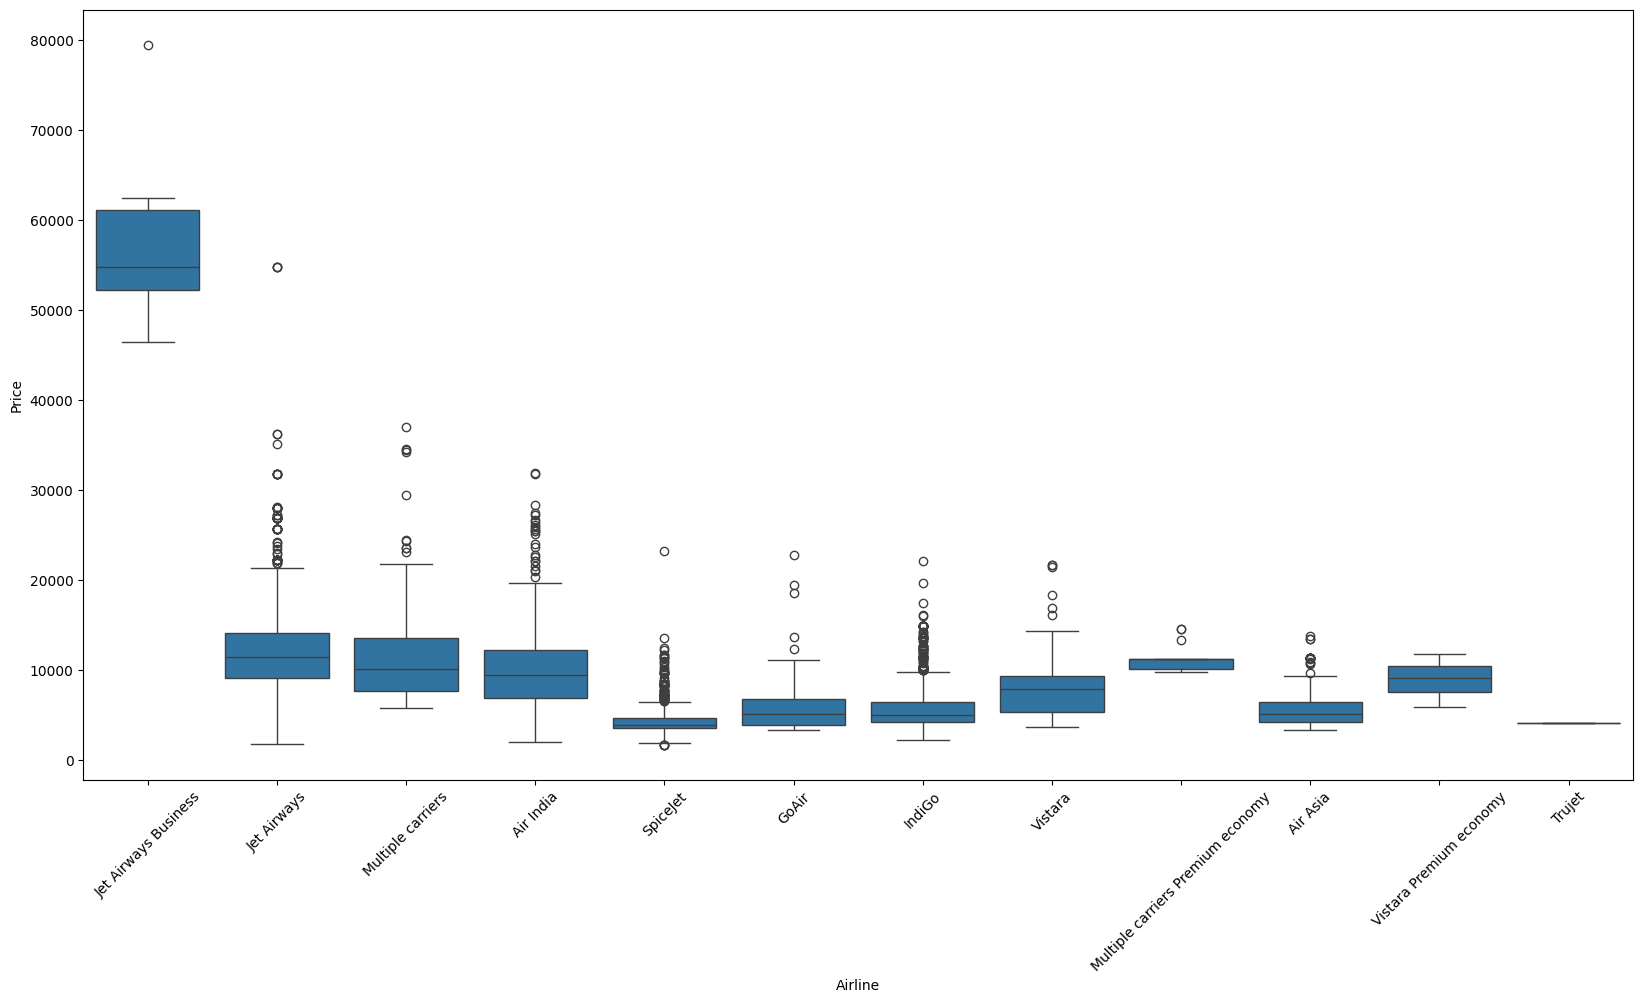

In [32]:
plt.figure(figsize=(20, 10))
sns.boxplot(y='Price', x='Airline', data=df.sort_values('Price', ascending=False))
plt.xticks(rotation=45)
plt.show()

Price based on number of stops



In [33]:
print(df.groupby(['Airline', 'Total_Stops'])['Price'].mean())

Airline                            Total_Stops
Air Asia                           1 stop          7078.325581
                                   2 stops         6341.888889
                                   non-stop        4492.331492
Air India                          1 stop          9041.509259
                                   2 stops        12092.779101
                                   3 stops        12208.054054
                                   4 stops        17686.000000
                                   non-stop        5605.326139
GoAir                              1 stop          6884.676471
                                   non-stop        4726.173913
IndiGo                             1 stop          7104.717528
                                   2 stops         7507.526316
                                   non-stop        4731.174053
Jet Airways                        1 stop         12512.741223
                                   2 stops        13387.247467
        

Bar Plot 

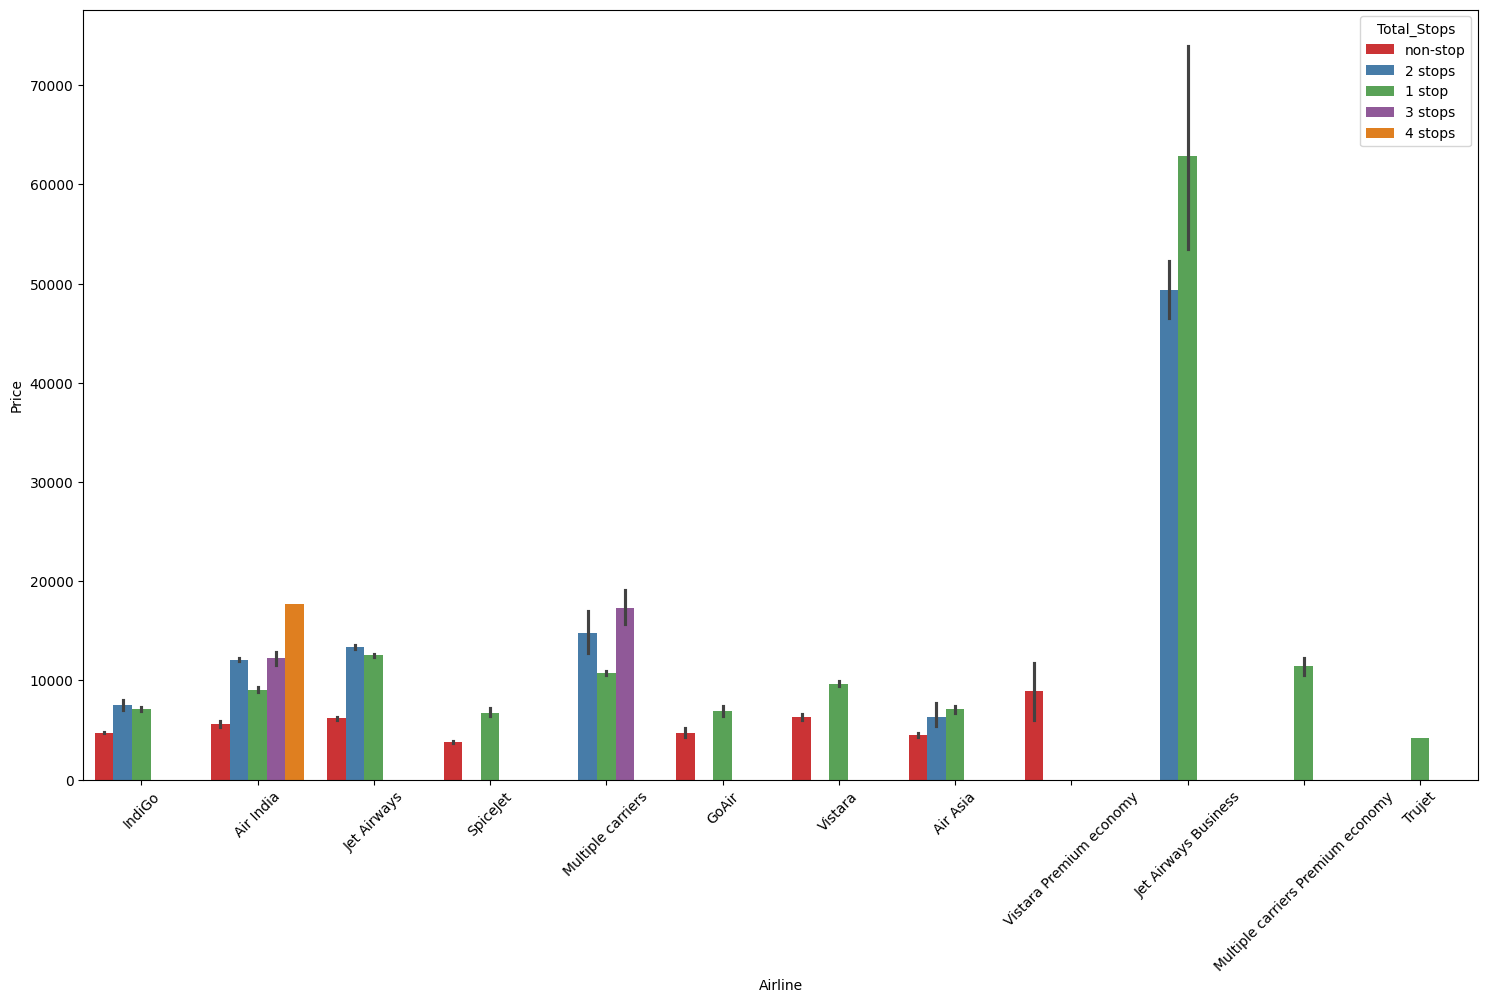

In [ ]:
plt.figure(figsize=(18,10))
ax = sns.barplot(x=df['Airline'], y=df['Price'], hue=df['Total_Stops'], palette='Set1')
plt.xticks(rotation = 45)
plt.show()

Number of flights from different Airports

In [35]:
print (df['Source'].value_counts())

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64


Source vs Price

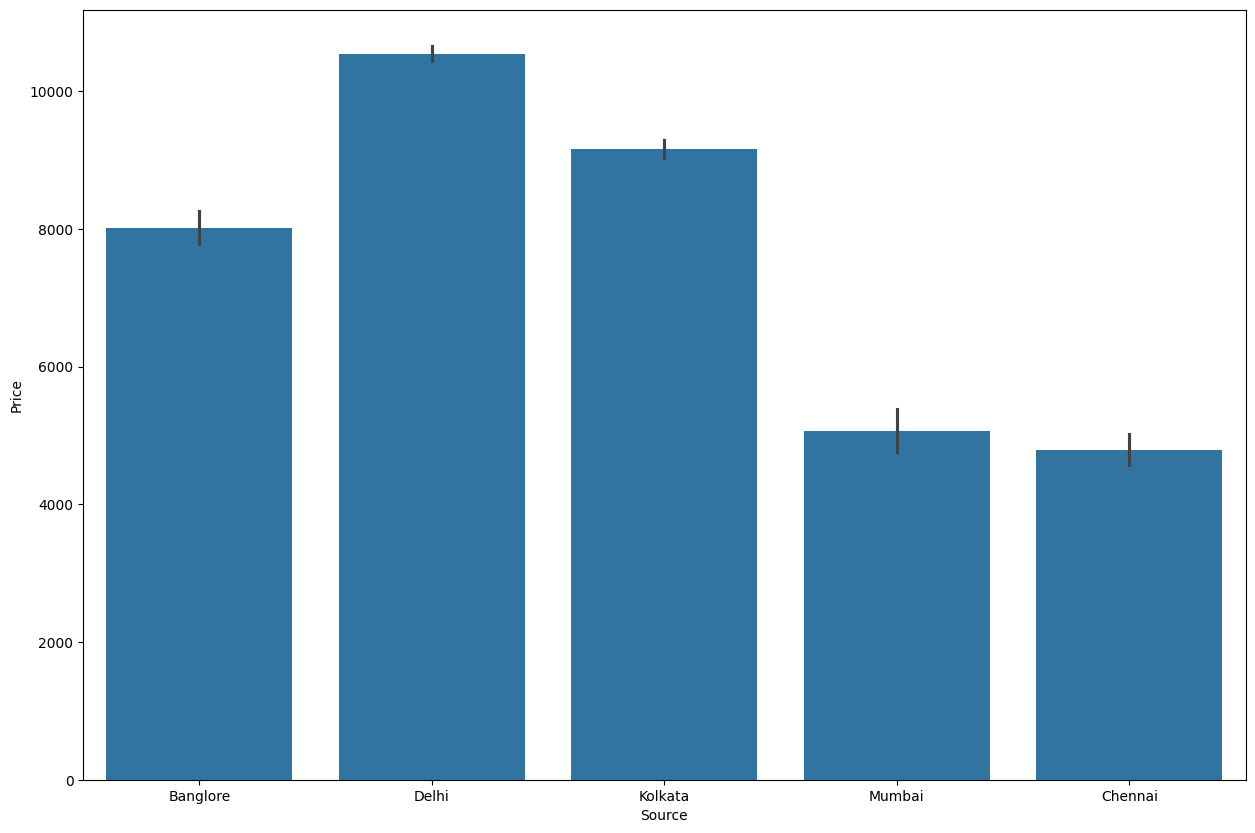

In [37]:
plt.figure(figsize=(15,10))
sns.barplot(y='Price', x='Source', data=df.sort_values('Price', ascending=False))
plt.show()

Flights in the destination

In [38]:
print (df['Destination'].value_counts())

Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64


Destination vs Price

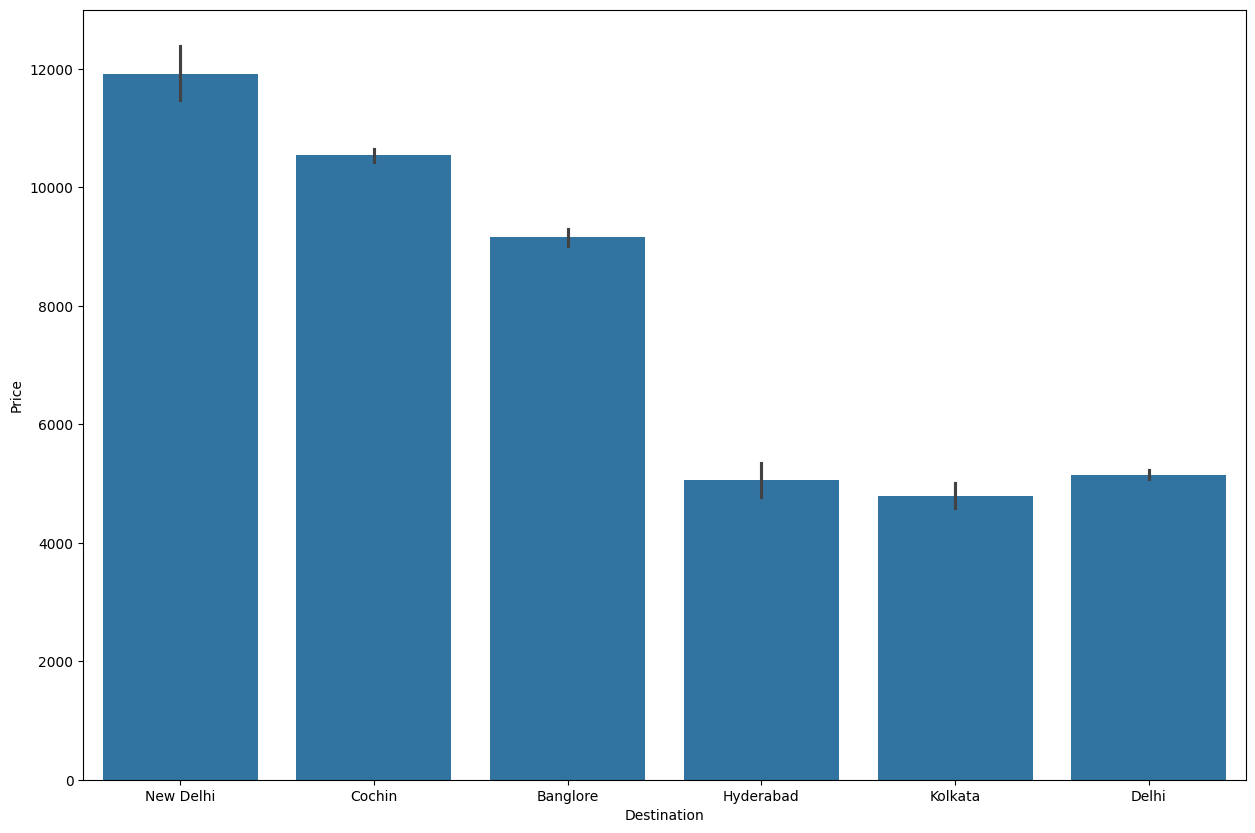

In [39]:
plt.figure(figsize=(15,10))
sns.barplot(y='Price',x='Destination',data=df.sort_values('Price',ascending=False))
plt.show()


There is New Delhi and Delhi in the data set, replace New Delhi with Delhi

In [40]:
for i in df:
    df.replace('New Delhi', 'Delhi', inplace=True)

Display Unique Destinations

In [41]:
display(df['Destination'].unique())


array(['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad'],
      dtype=object)

Flights in the destination after consolidation

In [42]:
print(df['Destination'].value_counts())

Destination
Cochin       4536
Banglore     2871
Delhi        2197
Hyderabad     697
Kolkata       381
Name: count, dtype: int64


Create Bar Plot with Price 

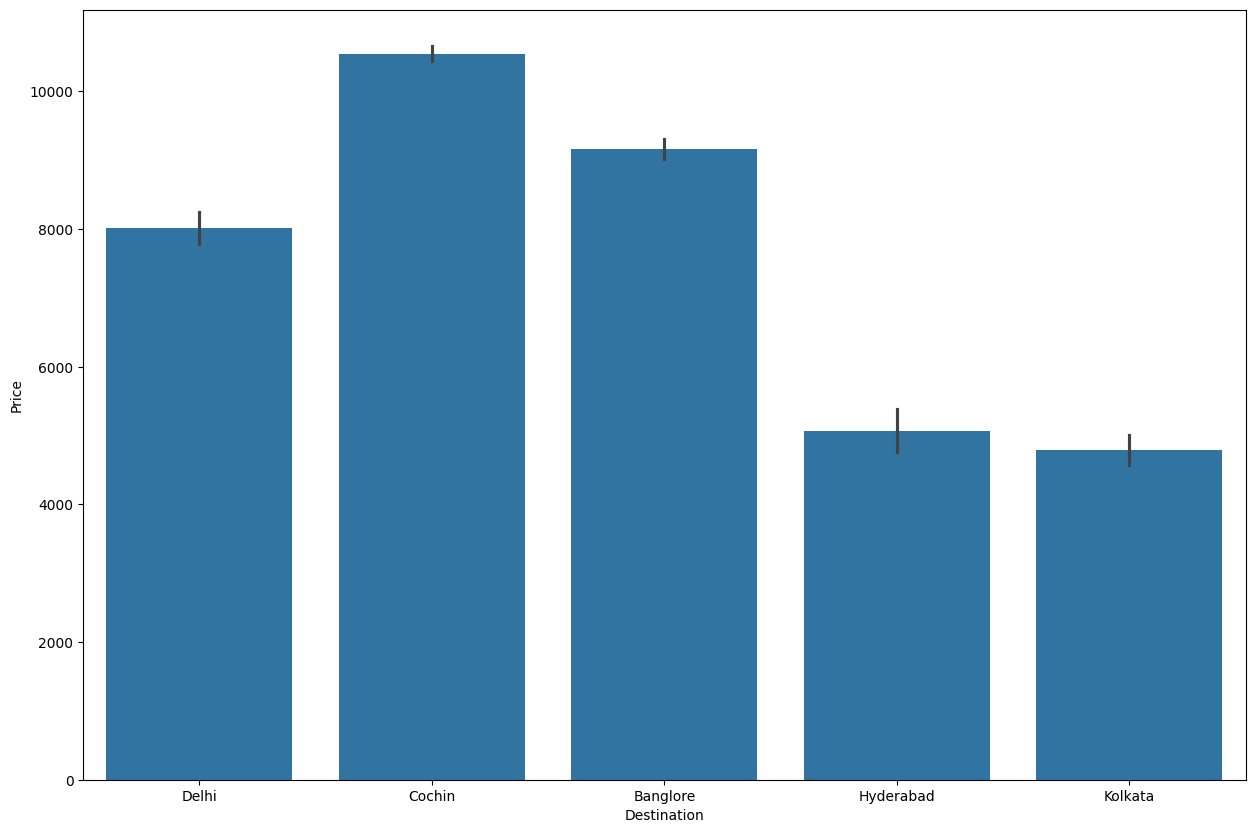

In [43]:
plt.figure(figsize=(15, 10))
sns.barplot(y='Price', x='Destination', data=df.sort_values('Price', ascending=False))
plt.show()

Display the Data 

In [44]:
display (df.head(2))

,Airline,Source,Destination,Route,Dep_Time,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,Duration_hr,duration_min
0,IndiGo,Banglore,Delhi,BLR → DEL,22:20,non-stop,No info,3897,24,3,22,20,1,10,0,m
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,2 stops,No info,7662,1,5,5,50,13,15,5,m


Create a data frame after removing string columns and Y variable 

In [45]:
df_corr = df.iloc[:,7:]
display(df_corr)

,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,Duration_hr,duration_min
0,3897,24,3,22,20,1,10,0,m
1,7662,1,5,5,50,13,15,5,m
2,13882,9,6,9,25,4,25,O,M
3,6218,12,5,18,5,23,30,5,m
4,13302,1,3,16,50,21,35,5,m
...,...,...,...,...,...,...,...,...,...
10678,4107,9,4,19,55,22,25,0,m
10679,4145,27,4,20,45,23,20,5,m
10680,7229,27,4,8,20,11,20,O,M
10681,12648,1,3,11,30,14,10,0,m


#The features are less correlated which is a good thing for us to avoid Multicollinearity

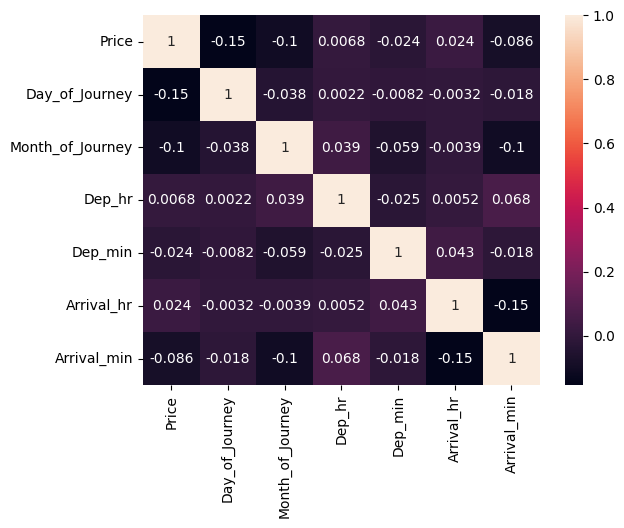

In [46]:
sns.heatmap(df_corr.select_dtypes(include='number').corr(), annot=True)
plt.show()


One Hot Encoding 

# Label Encoding - Column 'Total_Stops'

In [ ]:
df['Total_Stops'] = df['Total_Stops'].map({'non-stop':0, '2 stop':1, '1 stop':2, '3 stop':3, '4 stop':3})
display(df.head(4))

,Airline,Source,Destination,Route,Dep_Time,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,Duration_hr,duration_min
0,IndiGo,Banglore,Delhi,BLR → DEL,22:20,0.0,No info,3897,24,3,22,20,1,10,0,m
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,NaN,No info,7662,1,5,5,50,13,15,5,m
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,NaN,No info,13882,9,6,9,25,4,25,O,M
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,2.0,No info,6218,12,5,18,5,23,30,5,m


One Hot Encoding -Column "Airline"- Due to drop_first, there is no column for Air Asia

In [48]:
air_dummy =pd.get_dummies(df['Airline'], drop_first=True, dtype=int)
display(air_dummy)

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
10678,0,0,0,0,0,0,0,0,0,0,0
10679,1,0,0,0,0,0,0,0,0,0,0
10680,0,0,0,1,0,0,0,0,0,0,0
10681,0,0,0,0,0,0,0,0,0,1,0


#One hot encoding for columns 'Source','Destination' Due to drop first Source Cochin column Dropped 

In [49]:
source_dest_dummy = pd.get_dummies(df[['Source', 'Destination']], drop_first=True, dtype=int)
display(source_dest_dummy)

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata
0,0,0,0,0,0,1,0,0
1,0,0,1,0,0,0,0,0
2,0,1,0,0,1,0,0,0
3,0,0,1,0,0,0,0,0
4,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...
10678,0,0,1,0,0,0,0,0
10679,0,0,1,0,0,0,0,0
10680,0,0,0,0,0,1,0,0
10681,0,0,0,0,0,1,0,0


Concatenate Label Encoded and one hot encoded columns into main data frame

In [50]:
df =pd.concat([air_dummy,source_dest_dummy,df], axis=1)
display(df.head(4))

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,...,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,Duration_hr,duration_min
0,0,0,1,0,0,0,0,0,0,0,...,No info,3897,24,3,22,20,1,10,0,m
1,1,0,0,0,0,0,0,0,0,0,...,No info,7662,1,5,5,50,13,15,5,m
2,0,0,0,1,0,0,0,0,0,0,...,No info,13882,9,6,9,25,4,25,O,M
3,0,0,1,0,0,0,0,0,0,0,...,No info,6218,12,5,18,5,23,30,5,m


#Drop Columns -Already Label Encoded or One Hot Encoded 

In [51]:
df.drop(['Airline', 'Source', 'Destination'], inplace=True, axis=1)

Display -Shapes 

In [52]:
display (df.shape)

(10682, 32)

Read Test Data

In [54]:
df_test= pd.read_excel(r"E:\ML_Pro\Flight_Price_Prd\data\Test_set.xlsx")
display(df_test) 


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info
...,...,...,...,...,...,...,...,...,...,...
2666,Air India,6/06/2019,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info
2667,IndiGo,27/03/2019,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info
2668,Jet Airways,6/03/2019,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info
2669,Air India,6/03/2019,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info


#Column - 'Date_of_Journey' – Extract Day and month  

In [55]:
df_test['Date_of_Journey'] =pd.to_datetime(df_test['Date_of_Journey'],dayfirst=True)
df_test['Day_of_Journey'] =(df_test['Date_of_Journey']).dt.day
df_test['Month_of_Journey'] =(df_test['Date_of_Journey']).dt.day



In [56]:
df_test['Dep_hr']=pd.to_datetime(df_test['Dep_Time'], format='%H:%M').dt.hour
df_test['Dep_min']=pd.to_datetime(df_test['Dep_Time'], format='%H:%M').dt.minute

Arrival Time

In [57]:
df_test['Arrival_hr']=pd.to_datetime(df_test['Arrival_Time'], format='mixed').dt.hour
df_test['Arrival_minute']=pd.to_datetime(df_test['Arrival_Time'], format='mixed').dt.minute


#dropping the data

In [58]:
df_test.drop(['Date_of_Journey', 'Duration', 'Arrival_Time', 'Dep_Time'], inplace=True, axis=1)

#Handling Categorical Values 

In [59]:
df_test['Total_Stops'] =df_test['Total_Stops'].map({'non-stop': 0, '2 stop': 2, '1 stop': 1, '3 stop': 3, '4 stop': 4})
air_dummy =pd.get_dummies(df_test['Airline'], drop_first=True, dtype=int)
source_dest_dummy =pd.get_dummies(df_test[['Source', 'Destination']], drop_first=True, dtype=int)

df_test = pd.concat([air_dummy, source_dest_dummy, df_test], axis=1)

In [60]:
df_test.drop(['Airline','Source','Destination','Additional_Info',"Route"],inplace=True,axis=1)
display (df_test.head(4))

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Vistara,Vistara Premium economy,...,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Total_Stops,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_minute
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1.0,6,6,17,30,4,25
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1.0,12,12,6,20,10,20
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1.0,21,21,19,15,19,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1.0,21,21,8,0,21,0


In [61]:
print('train_shape',df.shape)

train_shape (10682, 32)


In [62]:
print('test_shape',df_test.shape)

test_shape (2671, 26)


Create X and Y from Training Data

In [ ]:
x=df.drop(['Dep_Time','Route', 'Price','Additional_Info'], axis=1)
# Hours extract
x['Duration_hr'] = (
    x['Duration_hr']
    .str.extract('(\d+)')
    .fillna(0)
    .astype(int)
)

# Minutes extract
x['duration_min'] = (
    x['duration_min']
    .str.extract('(\d+)')
    .fillna(0)
    .astype(int)
)

y=df['Price']

<>:5: SyntaxWarning:

invalid escape sequence '\d'

<>:13: SyntaxWarning:

invalid escape sequence '\d'

<>:5: SyntaxWarning:

invalid escape sequence '\d'

<>:13: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\hp\AppData\Local\Temp\ipykernel_9860\1702919385.py:5: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\hp\AppData\Local\Temp\ipykernel_9860\1702919385.py:13: SyntaxWarning:

invalid escape sequence '\d'



In [64]:
x.select_dtypes(include='object').columns


Index([], dtype='object')

Display X 

In [65]:
display (x.head(3))

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,...,Destination_Kolkata,Total_Stops,Day_of_Journey,Month_of_Journey,Dep_hr,Dep_min,Arrival_hr,Arrival_min,Duration_hr,duration_min
0,0,0,1,0,0,0,0,0,0,0,...,0,0.0,24,3,22,20,1,10,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,NaN,1,5,5,50,13,15,5,0
2,0,0,0,1,0,0,0,0,0,0,...,0,NaN,9,6,9,25,4,25,0,0


Model Building 

In [66]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score
ET_MODEL = ExtraTreesRegressor()
ET_MODEL.fit(x,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


Predict and Print Accuracy 

In [67]:
y_preict=ET_MODEL.predict(x)
display(r2_score(y, y_preict))

0.9618197485299991

Feature Importance Graph

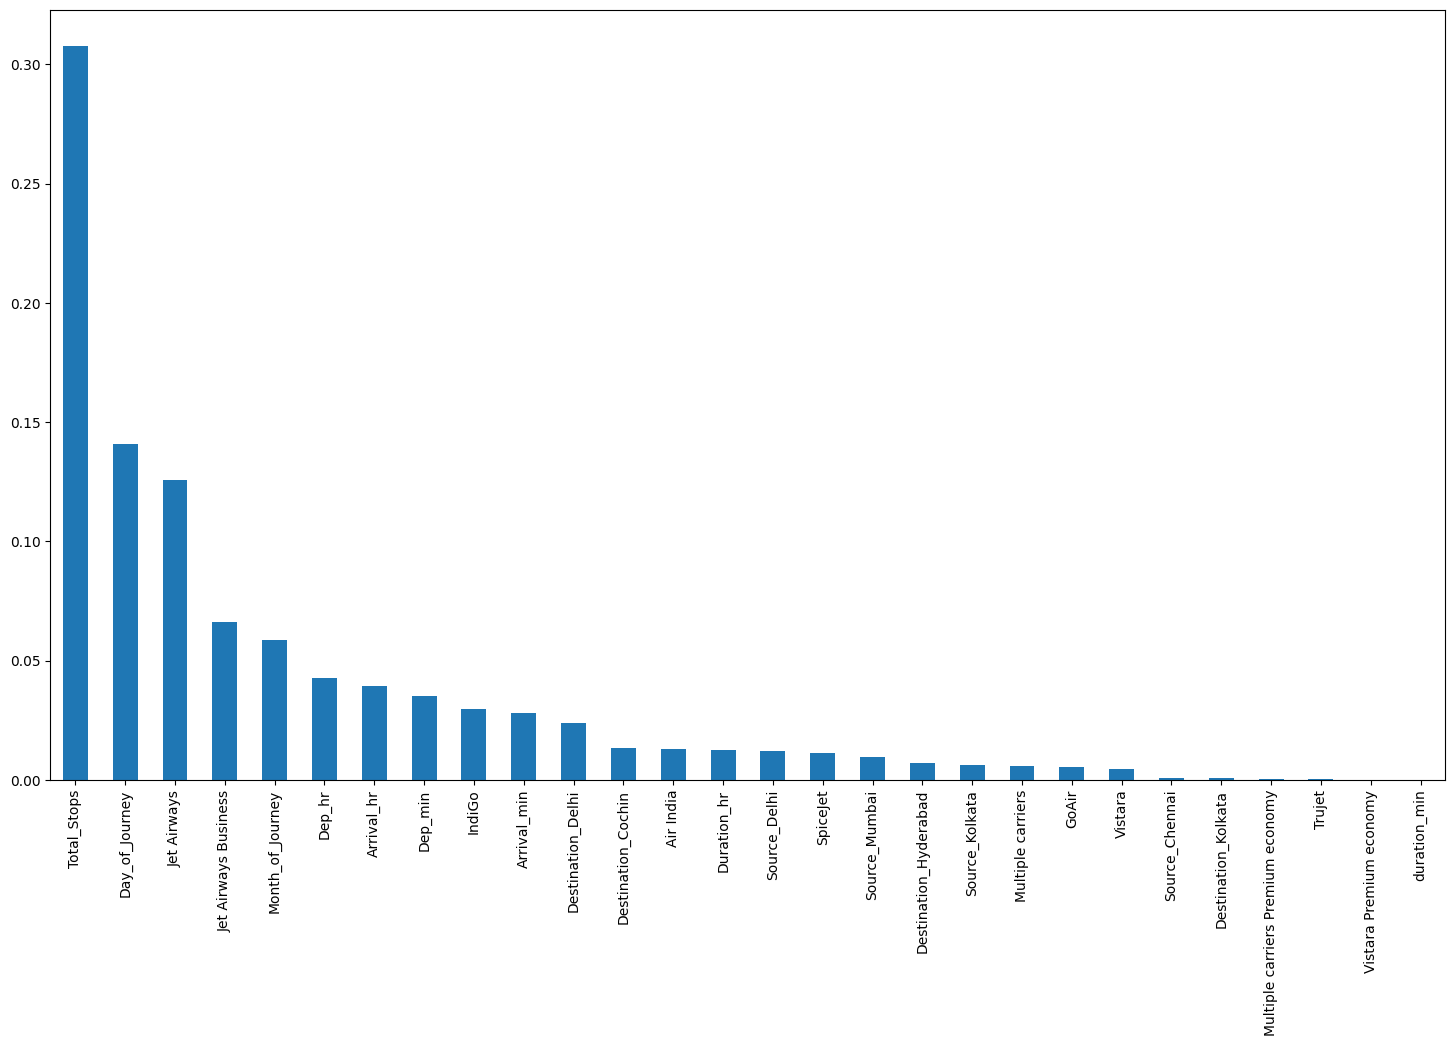

In [68]:
pd.Series(ET_MODEL.feature_importances_, index=x.columns).sort_values(ascending=False).plot(kind='bar', figsize=(18, 10))
plt.show()

Train Test Split

In [71]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=50)

Create Model Extra Tree Regression 

In [72]:
from sklearn.ensemble import ExtraTreesRegressor
ET_MODEL=ExtraTreesRegressor(n_estimators=120)
ET_MODEL.fit(x_train, y_train)

,n_estimators,120
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


Prediction and Print Accuracy for the test data 

In [73]:
y_preict = ET_MODEL.predict(x_test)
from sklearn.metrics import r2_score
display(r2_score(y_test, y_preict))

0.7427996590893147

Prediction and Print Accuracy for the training data 

In [74]:
y_train_predict = ET_MODEL.predict(x_train)
from sklearn.metrics import r2_score
display(r2_score(y_train, y_train_predict))

0.9677788922158215

Random Forest Regressor

In [75]:
from sklearn.ensemble import RandomForestRegressor
RF_MODEL =RandomForestRegressor()
RF_MODEL.fit(x_train, y_train)

print('Accuracy with test data')
y_predict =RF_MODEL.predict(x_test)
print(r2_score(y_test, y_predict))
print()
print("Accuracy with Training Data")
y_train_predict =RF_MODEL.predict(x_train)
print(r2_score(y_train, y_train_predict))

Accuracy with test data
0.8082306263964274

Accuracy with Training Data
0.9529501265158562


Parameter Gird

In [77]:
from sklearn.model_selection import RandomizedSearchCV
n_estimators = [int(x) for x in np.linspace(start=80, stop = 1500, num = 10)]
max_features = ['log2', 'sqrt']
max_depth = [int(x) for x in np.linspace(6,45, num=5)]
min_samples_split = [2,5,10, 15, 100]
min_samples_leaf = [1, 2, 5, 10]





In [78]:
rand_grid = {
    'n_estimators': n_estimators,
    'max_features': ['sqrt', 'log2'],
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf
}


Create the model with parameters

In [79]:
rf = RandomForestRegressor()

rCV = RandomizedSearchCV(estimator = rf, param_distributions=rand_grid,scoring='neg_mean_squared_error', n_iter=50,
                         cv=5, random_state=42, n_jobs=1)



Fit Model

In [ ]:
rCV.fit(x_train, y_train)

Prediction 

In [ ]:
rf_pred = rCV.predict(x_test)
display(rf_pred)

Mean_absolute_error and mean_squared_error

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print('MEA',mean_absolute_error(y_test,rf_pred))
print('MSE', mean_squared_error(y_test,rf_pred))

Display Accuracy

In [ ]:
display(r2_score(y_test,rf_pred))

Display Error and Accuracy with Training Data 

In [ ]:
rf_train_pred = rCV.predict(x_train)
print('MAE', mean_absolute_error(y_train, rf_train_pred))
print('MSE', mean_squared_error(y_train, rf_train_pred))
print()
print ('Accuracy')
print (r2_score(y_train,rf_train_pred))


Model CatBoostRegressor

In [ ]:
from catboost import CatBoostRegressor
cat = CatBoostRegressor()
cat.fit(x_train, y_train)

In [ ]:
cat_pred = cat.predict(x_test)
display(cat_pred)

In [ ]:
display(r2_score(y_test, cat_pred))

Change Data type for Light GBM 

In [ ]:
x_train [['Duration_hr', 'duration_min']] = x_train[['Duration_hr', 'duration_min']]
x_test[['Duration_hr', 'duration_min']] = x_test[['Duration_hr', 'duration_min']]

Create Model Light GBM Regressor

In [ ]:
from lightgbm import LGBMRegressor
lgb_model = LGBMRegressor()
lgb_model.fit(x_train, y_train)

Prediction and display accuracy 

In [ ]:
lgb_pred = lgb_model.predict(x_test)
display(r2_score(y_test, lgb_pred))

Create Model XG Boost Regressor 

In [ ]:
import xgboost as xgb
xgb_model=xgb.XGBRegressor()
xgb_model.fit(x_train, y_train)
xgb_pred=xgb_model.predict(x_test)
display (r2_score(y_test,xgb_pred))



In [ ]:
df.head()

Create Pickle File 

In [ ]:
import pickle 
pickle.dump(cat, open('model.pkl','wb'))
model=pickle.load(open('model.pkl','rb'))


In [ ]:
display (df.columns)

In [ ]:
deploy_df=df.drop(['Route','Additional_Info'],axis=1)

In [ ]:
deploy_df.to_csv('deploy_df.csv')
display (deploy_df)
